# Predictia Pretului Automobilelor BMW

## Descrierea Problemei

### Obiectiv
Acest proiect abordeaza problema **predictiei pretului** automobilelor BMW pe baza caracteristicilor vehiculului. Aceasta este o problema de **invatare supervizata de tip regresie**.

### De ce este importanta aceasta problema?
- **Pentru cumparatori**: Verificarea daca pretul cerut este corect
- **Pentru vanzatori**: Stabilirea unui pret competitiv
- **Pentru dealeri**: Estimarea valorii stocului

### Metodele Utilizate
1. **Linear Regression** - Metoda simpla, bazata pe relatii liniare
2. **Random Forest Regressor** - Metoda complexa, ansamblu de arbori de decizie

### Setul de Date
Dataset-ul contine **10,781 inregistrari** de masini BMW cu urmatoarele caracteristici:

| Coloana | Descriere | Tip |
|---------|-----------|-----|
| model | Modelul BMW (ex: 3 Series, X5) | Categoric |
| year | Anul fabricatiei (1996-2020) | Numeric |
| price | **Pretul de vanzare in GBP (VARIABILA TINTA)** | Numeric |
| transmission | Tipul transmisiei | Categoric |
| mileage | Kilometrajul | Numeric |
| fuelType | Tipul combustibilului | Categoric |
| tax | Taxa rutiera anuala | Numeric |
| mpg | Consumul (mile per galon) | Numeric |
| engineSize | Capacitatea motorului | Numeric |

## 1. Importarea Bibliotecilor si Incarcarea Datelor

In [1]:
# Biblioteci principale
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings('ignore')

# Setari pentru vizualizari
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score

# Modele de Regresie
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Metrici de evaluare
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Bibliotecile au fost importate cu succes!')

Bibliotecile au fost importate cu succes!


In [2]:
# Incarcarea datelor
df = pd.read_csv('bmw.csv')

print(f'Dimensiunea dataset-ului: {df.shape[0]:,} randuri x {df.shape[1]} coloane')
print(f'Coloanele disponibile: {df.columns.tolist()}')
df.head(10)

Dimensiunea dataset-ului: 10,781 randuri x 9 coloane
Coloanele disponibile: ['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize']


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0
5,5 Series,2016,14900,Automatic,35309,Diesel,125,60.1,2.0
6,5 Series,2017,16000,Automatic,38538,Diesel,125,60.1,2.0
7,2 Series,2018,16250,Manual,10401,Petrol,145,52.3,1.5
8,4 Series,2017,14250,Manual,42668,Diesel,30,62.8,2.0
9,5 Series,2016,14250,Automatic,36099,Diesel,20,68.9,2.0


## 2. Explorarea si Analiza Datelor (EDA)

In [3]:
# Informatii generale despre dataset
print('Statistici descriptive pentru variabilele numerice:')
df.describe().round(2)

Statistici descriptive pentru variabilele numerice:


,year,price,mileage,tax,mpg,engineSize
count,10781.00,10781.00,10781.00,10781.00,10781.00,10781.00
mean,2017.08,22733.41,25496.99,131.70,56.40,2.17
std,2.35,11415.53,25143.19,61.51,31.34,0.55
min,1996.00,1200.00,1.00,0.00,5.50,0.00
25%,2016.00,14950.00,5529.00,135.00,45.60,2.00
50%,2017.00,20462.00,18347.00,145.00,53.30,2.00
75%,2019.00,27940.00,38206.00,145.00,62.80,2.00
max,2020.00,123456.00,214000.00,580.00,470.80,6.60


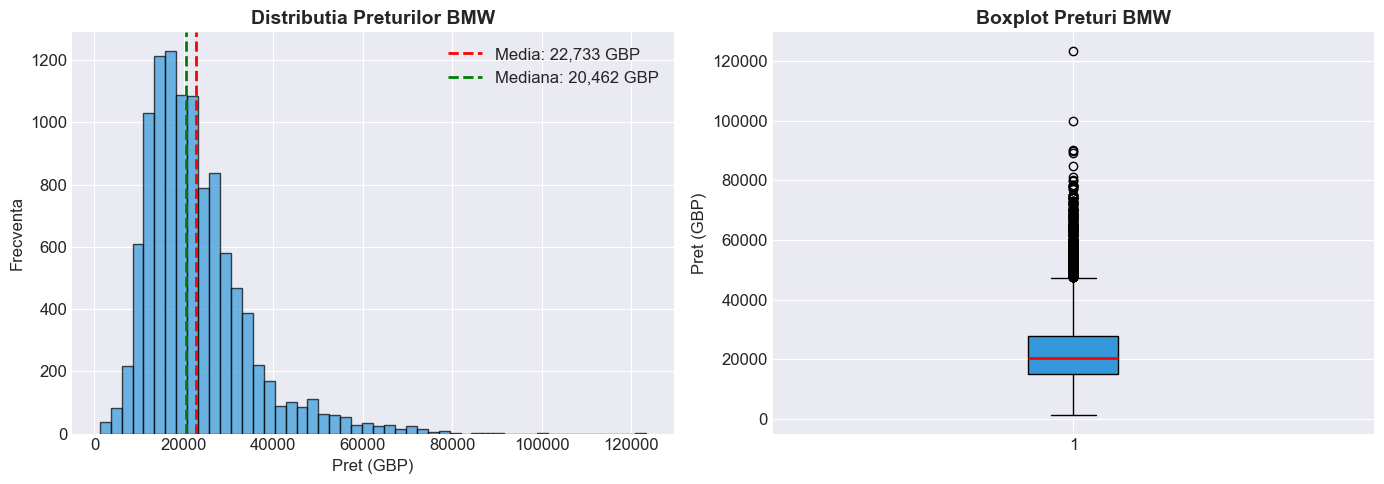


Statistici Pret:
   Min: 1,200 GBP
   Max: 123,456 GBP
   Media: 22,733.41 GBP
   Mediana: 20,462.0 GBP


In [4]:
# Distributia variabilei tinta (PRET)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['price'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].axvline(df['price'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["price"].mean():,.0f} GBP')
axes[0].axvline(df['price'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {df["price"].median():,.0f} GBP')
axes[0].set_xlabel('Pret (GBP)', fontsize=12)
axes[0].set_ylabel('Frecventa', fontsize=12)
axes[0].set_title('Distributia Preturilor BMW', fontsize=14, fontweight='bold')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['price'], patch_artist=True, 
                boxprops=dict(facecolor='#3498db', color='black'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Pret (GBP)', fontsize=12)
axes[1].set_title('Boxplot Preturi BMW', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('distributie_pret.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nStatistici Pret:')
print(f'   Min: {df["price"].min():,} GBP')
print(f'   Max: {df["price"].max():,} GBP')
print(f'   Media: {df["price"].mean():,.2f} GBP')
print(f'   Mediana: {df["price"].median():,} GBP')

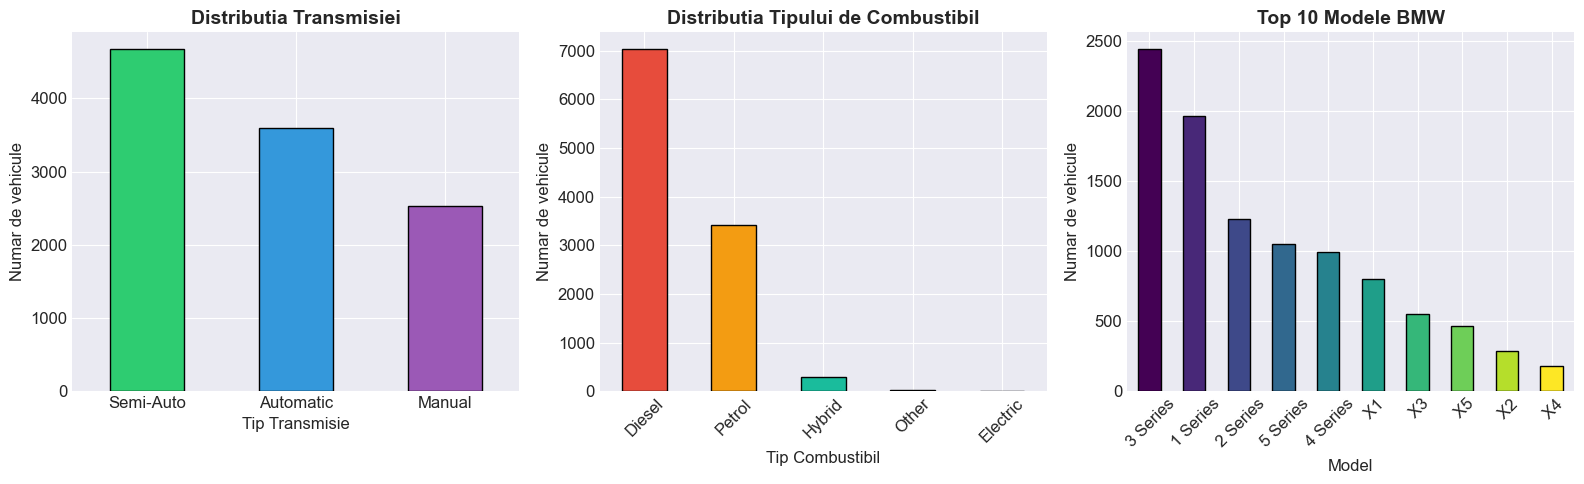

In [5]:
# Vizualizarea distributiei variabilelor categorice
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Transmisie
colors_transmission = ['#2ecc71', '#3498db', '#9b59b6']
df['transmission'].value_counts().plot(kind='bar', ax=axes[0], color=colors_transmission, edgecolor='black')
axes[0].set_title('Distributia Transmisiei', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tip Transmisie')
axes[0].set_ylabel('Numar de vehicule')
axes[0].tick_params(axis='x', rotation=0)

# Tip combustibil
colors_fuel = ['#e74c3c', '#f39c12', '#1abc9c', '#34495e', '#95a5a6']
df['fuelType'].value_counts().plot(kind='bar', ax=axes[1], color=colors_fuel, edgecolor='black')
axes[1].set_title('Distributia Tipului de Combustibil', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tip Combustibil')
axes[1].set_ylabel('Numar de vehicule')
axes[1].tick_params(axis='x', rotation=45)

# Top 10 modele
df['model'].value_counts().head(10).plot(kind='bar', ax=axes[2], color=plt.cm.viridis(np.linspace(0, 1, 10)), edgecolor='black')
axes[2].set_title('Top 10 Modele BMW', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Model')
axes[2].set_ylabel('Numar de vehicule')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('distributie_categorice.png', dpi=150, bbox_inches='tight')
plt.show()

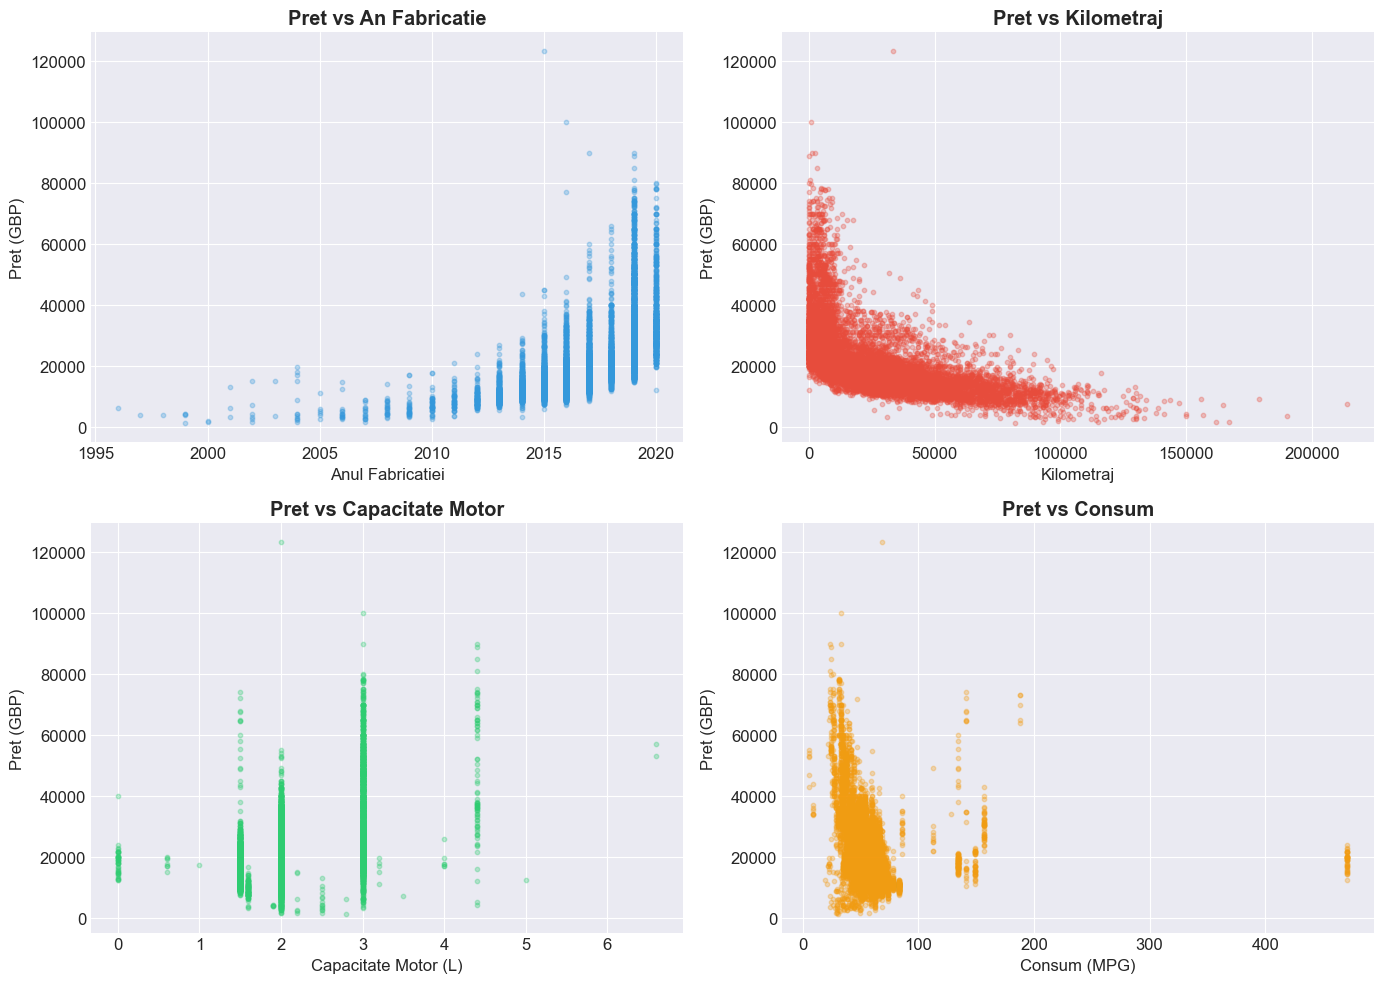

In [6]:
# Relatia dintre variabilele numerice si pret
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Pret vs An
axes[0, 0].scatter(df['year'], df['price'], alpha=0.3, c='#3498db', s=10)
axes[0, 0].set_xlabel('Anul Fabricatiei')
axes[0, 0].set_ylabel('Pret (GBP)')
axes[0, 0].set_title('Pret vs An Fabricatie', fontweight='bold')

# Pret vs Kilometraj
axes[0, 1].scatter(df['mileage'], df['price'], alpha=0.3, c='#e74c3c', s=10)
axes[0, 1].set_xlabel('Kilometraj')
axes[0, 1].set_ylabel('Pret (GBP)')
axes[0, 1].set_title('Pret vs Kilometraj', fontweight='bold')

# Pret vs Capacitate Motor
axes[1, 0].scatter(df['engineSize'], df['price'], alpha=0.3, c='#2ecc71', s=10)
axes[1, 0].set_xlabel('Capacitate Motor (L)')
axes[1, 0].set_ylabel('Pret (GBP)')
axes[1, 0].set_title('Pret vs Capacitate Motor', fontweight='bold')

# Pret vs MPG
axes[1, 1].scatter(df['mpg'], df['price'], alpha=0.3, c='#f39c12', s=10)
axes[1, 1].set_xlabel('Consum (MPG)')
axes[1, 1].set_ylabel('Pret (GBP)')
axes[1, 1].set_title('Pret vs Consum', fontweight='bold')

plt.tight_layout()
plt.savefig('pret_vs_caracteristici.png', dpi=150, bbox_inches='tight')
plt.show()

Observatii importante pentru alegerea metodei:
- Relatiile NU sunt perfect liniare (curburi vizibile)
- Exista interactiuni complexe intre variabile
- Aceasta sugereaza ca o metoda liniara simpla va avea limitari

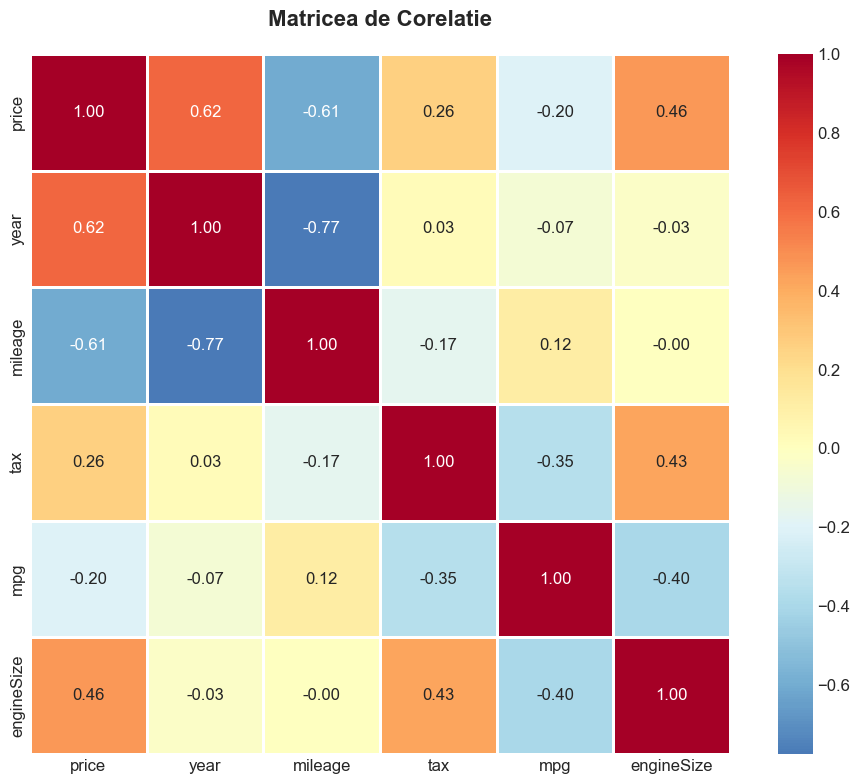


Corelatii cu pretul:
   year: 0.624 (puternica)
   engineSize: 0.460 (moderata)
   tax: 0.263 (slaba)
   mpg: -0.205 (slaba)
   mileage: -0.605 (puternica)


In [7]:
# Matrice de corelatie
plt.figure(figsize=(10, 8))
numeric_cols = ['price', 'year', 'mileage', 'tax', 'mpg', 'engineSize']
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu_r', center=0,
            square=True, linewidths=2, fmt='.2f', annot_kws={'size': 12})
plt.title('Matricea de Corelatie', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('matrice_corelatie.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCorelatii cu pretul:')
price_corr = correlation_matrix['price'].drop('price').sort_values(ascending=False)
for feature, corr in price_corr.items():
    strength = 'puternica' if abs(corr) > 0.5 else 'moderata' if abs(corr) > 0.3 else 'slaba'
    print(f'   {feature}: {corr:.3f} ({strength})')

## 3. Preprocesarea Datelor

### Pasii de preprocesare:

1. **Codificarea variabilelor categorice** - Transformarea textului in numere
   - model, transmission, fuelType -> valori numerice
   
2. **Impartirea datelor** - Set de antrenare (80%) si testare (20%)

3. **Standardizarea** - Aducerea valorilor la aceeasi scala (media=0, deviatie=1)

In [8]:
# Copie pentru preprocesare
df_prep = df.copy()

# 1. Codificarea variabilelor categorice folosind Label Encoding
# Label Encoding: transforma fiecare categorie intr-un numar unic
# Exemplu: 'Diesel'->0, 'Petrol'->1, 'Hybrid'->2

label_encoders = {}
categorical_cols = ['model', 'transmission', 'fuelType']

print('Codificarea variabilelor categorice:')
for col in categorical_cols:
    le = LabelEncoder()
    df_prep[col + '_encoded'] = le.fit_transform(df_prep[col])
    label_encoders[col] = le
    print(f'\n   {col}:')
    for idx, category in enumerate(le.classes_[:5]):
        print(f'      {category} -> {idx}')
    if len(le.classes_) > 5:
        print(f'      ... si inca {len(le.classes_) - 5} categorii')

Codificarea variabilelor categorice:

   model:
       1 Series -> 0
       2 Series -> 1
       3 Series -> 2
       4 Series -> 3
       5 Series -> 4
      ... si inca 19 categorii

   transmission:
      Automatic -> 0
      Manual -> 1
      Semi-Auto -> 2

   fuelType:
      Diesel -> 0
      Electric -> 1
      Hybrid -> 2
      Other -> 3
      Petrol -> 4


In [9]:
# 2. Definirea caracteristicilor (X) si variabilei tinta (y)

# Caracteristici pentru model (toate EXCEPTAND pretul)
feature_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 
                'model_encoded', 'transmission_encoded', 'fuelType_encoded']

X = df_prep[feature_cols]  # Caracteristici de intrare
y = df_prep['price']       # Variabila tinta (ce vrem sa prezicem)

print(f'Dimensiuni:')
print(f'   X (caracteristici): {X.shape} - {X.shape[0]} masini x {X.shape[1]} caracteristici')
print(f'   y (pret): {y.shape} - {y.shape[0]} valori de pret')

print(f'\nCaracteristicile utilizate:')
for i, col in enumerate(feature_cols, 1):
    print(f'   {i}. {col}')

Dimensiuni:
   X (caracteristici): (10781, 8) - 10781 masini x 8 caracteristici
   y (pret): (10781,) - 10781 valori de pret

Caracteristicile utilizate:
   1. year
   2. mileage
   3. tax
   4. mpg
   5. engineSize
   6. model_encoded
   7. transmission_encoded
   8. fuelType_encoded


In [10]:
# 3. Impartirea in set de antrenare si testare
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42
)

print(f'Impartirea datelor:')
print(f'   Set de antrenare: {len(X_train):,} exemple ({len(X_train)/len(X)*100:.0f}%)')
print(f'   Set de testare: {len(X_test):,} exemple ({len(X_test)/len(X)*100:.0f}%)')

Impartirea datelor:
   Set de antrenare: 8,624 exemple (80%)
   Set de testare: 2,157 exemple (20%)


In [11]:
# 4. Standardizarea caracteristicilor
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Standardizarea completa!')
print(f'\nExemplu (prima observatie inainte si dupa):')
print(f'   Inainte: {X_train.iloc[0].values[:4].round(2)}...')
print(f'   Dupa:    {X_train_scaled[0][:4].round(2)}...')

Standardizarea completa!

Exemplu (prima observatie inainte si dupa):
   Inainte: [2019.  9165.   145.    50.4]...
   Dupa:    [ 0.82 -0.65  0.23 -0.2 ]...


## 4. Metoda 1: Linear Regression (Regresia Liniara)

### Ce este Regresia Liniara?

**Linear Regression** este cea mai simpla metoda de regresie care presupune o **relatie liniara** intre variabilele de intrare si cea de iesire.

### Formula matematica:
```
y = b0 + b1*x1 + b2*x2 + ... + bn*xn
```
Unde:
- y = pretul prezis
- b0 = intercept (constanta)
- b1, b2, ..., bn = coeficienti (ponderile fiecarei caracteristici)
- x1, x2, ..., xn = caracteristicile (year, mileage, etc.)

### Avantaje:
- Simplu si rapid de antrenat
- Usor de interpretat (coeficienti clari)
- Nu sufera de overfitting

### Dezavantaje (IMPORTANTE!):
- **NU poate captura relatii non-liniare**
- **NU poate modela interactiuni intre variabile**
- Performanta limitata pe date complexe

In [12]:
# Crearea si antrenarea modelului Linear Regression
print('Antrenarea modelului Linear Regression...')

lr_model = LinearRegression()

# Antrenarea modelului
lr_model.fit(X_train_scaled, y_train)

print('Model Linear Regression antrenat cu succes!')
print(f'\nCoeficientii modelului (ponderile caracteristicilor):')
for feature, coef in zip(feature_cols, lr_model.coef_):
    print(f'   {feature}: {coef:,.2f}')
print(f'   Intercept: {lr_model.intercept_:,.2f}')

Antrenarea modelului Linear Regression...
Model Linear Regression antrenat cu succes!

Coeficientii modelului (ponderile caracteristicilor):
   year: 4,501.92
   mileage: -2,991.23
   tax: -629.46
   mpg: 129.13
   engineSize: 4,759.14
   model_encoded: 3,731.54
   transmission_encoded: 304.79
   fuelType_encoded: 593.83
   Intercept: 22,669.16


In [13]:
# Predictii cu Linear Regression
y_pred_lr = lr_model.predict(X_test_scaled)

# Calcularea metricilor de evaluare
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print('\nREZULTATE LINEAR REGRESSION:')
print('=' * 50)
print(f'   MAE (Mean Absolute Error):  {lr_mae:,.2f} GBP')
print(f'   RMSE (Root Mean Squared Error): {lr_rmse:,.2f} GBP')
print(f'   R2 Score: {lr_r2:.4f} ({lr_r2*100:.2f}%)')
print('=' * 50)

print(f'\nInterpretare:')
print(f'   - In medie, predictia greseste cu {lr_mae:,.0f} GBP')
print(f'   - Modelul explica doar {lr_r2*100:.1f}% din variatia pretului')
print(f'   - Aceasta performanta este LIMITATA din cauza relatiilor non-liniare!')


REZULTATE LINEAR REGRESSION:
   MAE (Mean Absolute Error):  3,996.76 GBP
   RMSE (Root Mean Squared Error): 5,786.72 GBP
   R2 Score: 0.7410 (74.10%)

Interpretare:
   - In medie, predictia greseste cu 3,997 GBP
   - Modelul explica doar 74.1% din variatia pretului
   - Aceasta performanta este LIMITATA din cauza relatiilor non-liniare!


In [14]:
# Cross-validation pentru Linear Regression
print('Cross-validation (5-fold) pentru Linear Regression...')

lr_cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='r2')

print(f'\nRezultate cross-validation:')
for i, score in enumerate(lr_cv_scores, 1):
    print(f'   Fold {i}: R2 = {score:.4f}')
print(f'\n   Media: {lr_cv_scores.mean():.4f} (+/-{lr_cv_scores.std():.4f})')

Cross-validation (5-fold) pentru Linear Regression...

Rezultate cross-validation:
   Fold 1: R2 = 0.7603
   Fold 2: R2 = 0.7535
   Fold 3: R2 = 0.7477
   Fold 4: R2 = 0.7488
   Fold 5: R2 = 0.7152

   Media: 0.7451 (+/-0.0156)


## 5. Metoda 2: Random Forest Regressor

### Ce este Random Forest?

**Random Forest** este un algoritm de **ansamblu** (ensemble) care combina mai multi arbori de decizie pentru a face predictii mai precise.

### Cum functioneaza:

```
Date de antrenare
        |
   +---------+
   |    |    |
   v    v    v
Arbore1 Arbore2 ... ArboreN  <- Fiecare pe subset aleator
   |    |    |
   v    v    v
Pred1  Pred2  PredN
   +---------+
        |
        v
   MEDIA = Predictia finala
```

### Avantaje (fata de Linear Regression):
- **POATE captura relatii non-liniare** - fiecare arbore poate face split-uri complexe
- **POATE modela interactiuni** - arborii invata combinatii de variabile
- Robust la overfitting (prin agregarea mai multor arbori)
- Nu necesita presupuneri despre distributia datelor

### Dezavantaje:
- Mai greu de interpretat
- Necesita mai mult timp de antrenare

In [15]:
# Crearea si antrenarea modelului Random Forest
print('Antrenarea modelului Random Forest...')

rf_model = RandomForestRegressor(
    n_estimators=100,      # 100 de arbori in padure
    max_depth=15,          # Adancimea maxima a fiecarui arbore
    #min_samples_split=5,   # Minim 5 exemple pentru a diviza un nod
    #min_samples_leaf=2,    # Minim 2 exemple in fiecare frunza
    random_state=42,       # Pentru reproducibilitate
    n_jobs=-1              # Foloseste toate procesoarele
)

# Antrenarea modelului
rf_model.fit(X_train_scaled, y_train)

print('Model Random Forest antrenat cu succes!')
print(f'   Numar de arbori: {rf_model.n_estimators}')
print(f'   Adancime maxima: {rf_model.max_depth}')

Antrenarea modelului Random Forest...
Model Random Forest antrenat cu succes!
   Numar de arbori: 100
   Adancime maxima: 15


In [16]:
# Predictii cu Random Forest
y_pred_rf = rf_model.predict(X_test_scaled)

# Calcularea metricilor de evaluare
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print('\nREZULTATE RANDOM FOREST:')
print('=' * 50)
print(f'   MAE (Mean Absolute Error):  {rf_mae:,.2f} GBP')
print(f'   RMSE (Root Mean Squared Error): {rf_rmse:,.2f} GBP')
print(f'   R2 Score: {rf_r2:.4f} ({rf_r2*100:.2f}%)')
print('=' * 50)

print(f'\nInterpretare:')
print(f'   - In medie, predictia greseste cu doar {rf_mae:,.0f} GBP')
print(f'   - Modelul explica {rf_r2*100:.1f}% din variatia pretului')
print(f'   - Performanta SEMNIFICATIV mai buna decat Linear Regression!')


REZULTATE RANDOM FOREST:
   MAE (Mean Absolute Error):  1,633.08 GBP
   RMSE (Root Mean Squared Error): 2,684.39 GBP
   R2 Score: 0.9443 (94.43%)

Interpretare:
   - In medie, predictia greseste cu doar 1,633 GBP
   - Modelul explica 94.4% din variatia pretului
   - Performanta SEMNIFICATIV mai buna decat Linear Regression!


In [17]:
# Cross-validation pentru Random Forest
print('Cross-validation (5-fold) pentru Random Forest...')

rf_cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='r2')

print(f'\nRezultate cross-validation:')
for i, score in enumerate(rf_cv_scores, 1):
    print(f'   Fold {i}: R2 = {score:.4f}')
print(f'\n   Media: {rf_cv_scores.mean():.4f} (+/-{rf_cv_scores.std():.4f})')

Cross-validation (5-fold) pentru Random Forest...

Rezultate cross-validation:
   Fold 1: R2 = 0.9550
   Fold 2: R2 = 0.9544
   Fold 3: R2 = 0.9484
   Fold 4: R2 = 0.9470
   Fold 5: R2 = 0.9130

   Media: 0.9436 (+/-0.0156)


## 6. Comparatia Rezultatelor

In [18]:
# Tabel comparativ
print('\n' + '=' * 70)
print('COMPARATIE MODELE DE REGRESIE')
print('=' * 70)

comparison_df = pd.DataFrame({
    'Metrica': ['MAE (GBP)', 'RMSE (GBP)', 'R2 Score'],
    'Linear Regression': [f'{lr_mae:,.2f}', f'{lr_rmse:,.2f}', f'{lr_r2:.4f}'],
    'Random Forest': [f'{rf_mae:,.2f}', f'{rf_rmse:,.2f}', f'{rf_r2:.4f}']
})

comparison_df.set_index('Metrica', inplace=True)
comparison_df


COMPARATIE MODELE DE REGRESIE


,Linear Regression,Random Forest
Metrica,,
MAE (GBP),"3,996.76","1,633.08"
RMSE (GBP),"5,786.72","2,684.39"
R2 Score,0.7410,0.9443


In [19]:
# Calcul imbunatatire
mae_improvement = ((lr_mae - rf_mae) / lr_mae) * 100
r2_improvement = ((rf_r2 - lr_r2) / lr_r2) * 100

print('\n' + '=' * 70)
print('IMBUNATATIREA RANDOM FOREST FATA DE LINEAR REGRESSION')
print('=' * 70)
print(f'\n   MAE redus cu: {mae_improvement:.1f}%')
print(f'   R2 crescut cu: {r2_improvement:.1f}%')
print(f'\n   Random Forest prezice cu {lr_mae - rf_mae:,.0f} GBP mai precis!')


IMBUNATATIREA RANDOM FOREST FATA DE LINEAR REGRESSION

   MAE redus cu: 59.1%
   R2 crescut cu: 27.4%

   Random Forest prezice cu 2,364 GBP mai precis!


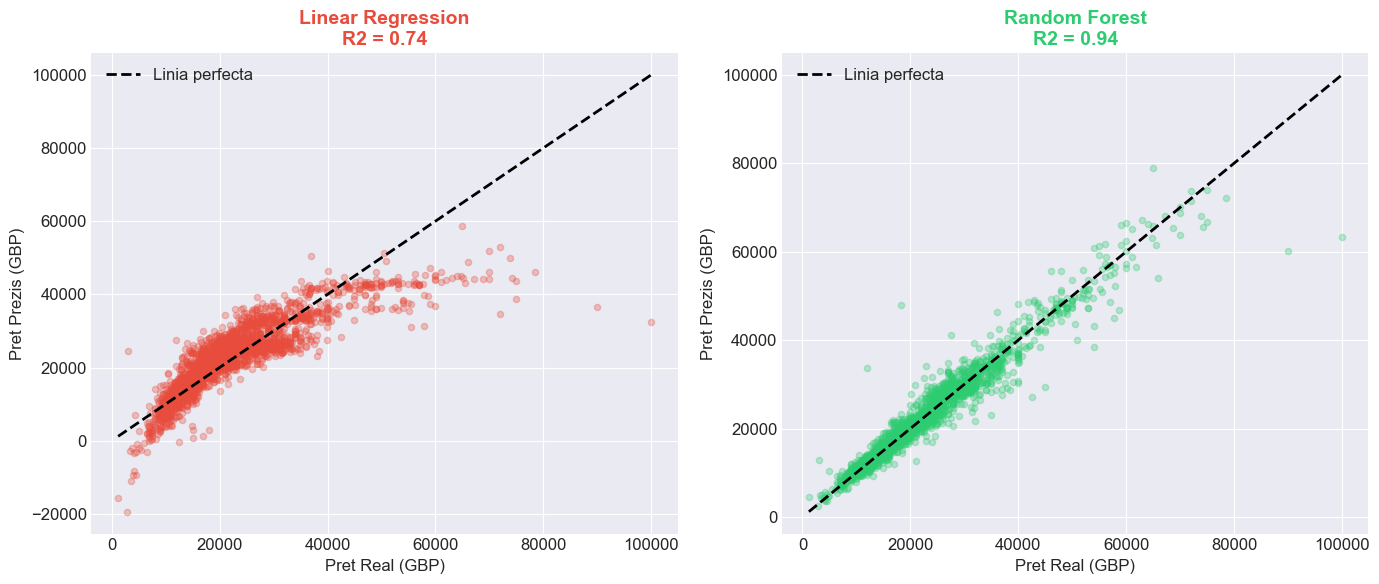

In [20]:
# Predictii vs Valori Reale - Comparatie vizuala clara
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Linear Regression
axes[0].scatter(y_test, y_pred_lr, alpha=0.3, c='#e74c3c', s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'k--', linewidth=2, label='Linia perfecta')
axes[0].set_xlabel('Pret Real (GBP)', fontsize=12)
axes[0].set_ylabel('Pret Prezis (GBP)', fontsize=12)
axes[0].set_title(f'Linear Regression\nR2 = {lr_r2:.2f}', fontsize=14, fontweight='bold', color='#e74c3c')
axes[0].legend()

# Random Forest
axes[1].scatter(y_test, y_pred_rf, alpha=0.3, c='#2ecc71', s=20)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'k--', linewidth=2, label='Linia perfecta')
axes[1].set_xlabel('Pret Real (GBP)', fontsize=12)
axes[1].set_ylabel('Pret Prezis (GBP)', fontsize=12)
axes[1].set_title(f'Random Forest\nR2 = {rf_r2:.2f}', fontsize=14, fontweight='bold', color='#2ecc71')
axes[1].legend()

plt.tight_layout()
plt.savefig('predictii_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()

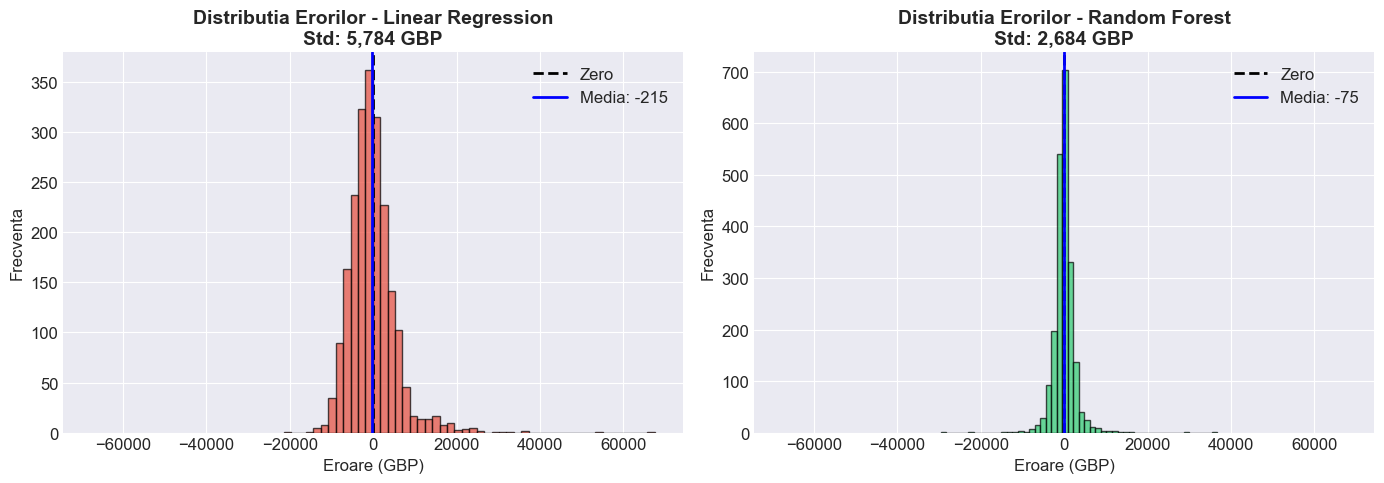

Interpretare:
   - Linear Regression: Distributie larga (std=5,784 GBP) = erori mari
   - Random Forest: Distributie ingusta (std=2,684 GBP) = erori mici


In [21]:
# Distributia erorilor - comparatie vizuala
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Erori Linear Regression
lr_errors = y_test - y_pred_lr
axes[0].hist(lr_errors, bins=50, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='black', linestyle='--', linewidth=2, label='Zero')
axes[0].axvline(lr_errors.mean(), color='blue', linestyle='-', linewidth=2, label=f'Media: {lr_errors.mean():,.0f}')
axes[0].set_xlabel('Eroare (GBP)', fontsize=12)
axes[0].set_ylabel('Frecventa', fontsize=12)
axes[0].set_title(f'Distributia Erorilor - Linear Regression\nStd: {lr_errors.std():,.0f} GBP', fontsize=14, fontweight='bold')
axes[0].legend()

# Erori Random Forest
rf_errors = y_test - y_pred_rf
axes[1].hist(rf_errors, bins=50, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='black', linestyle='--', linewidth=2, label='Zero')
axes[1].axvline(rf_errors.mean(), color='blue', linestyle='-', linewidth=2, label=f'Media: {rf_errors.mean():,.0f}')
axes[1].set_xlabel('Eroare (GBP)', fontsize=12)
axes[1].set_ylabel('Frecventa', fontsize=12)
axes[1].set_title(f'Distributia Erorilor - Random Forest\nStd: {rf_errors.std():,.0f} GBP', fontsize=14, fontweight='bold')
axes[1].legend()

# Setam acelasi range pe axa X pentru comparatie corecta
max_error = max(abs(lr_errors.min()), abs(lr_errors.max()), abs(rf_errors.min()), abs(rf_errors.max()))
axes[0].set_xlim([-max_error*1.1, max_error*1.1])
axes[1].set_xlim([-max_error*1.1, max_error*1.1])

plt.tight_layout()
plt.savefig('distributie_erori.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretare:')
print(f'   - Linear Regression: Distributie larga (std={lr_errors.std():,.0f} GBP) = erori mari')
print(f'   - Random Forest: Distributie ingusta (std={rf_errors.std():,.0f} GBP) = erori mici')

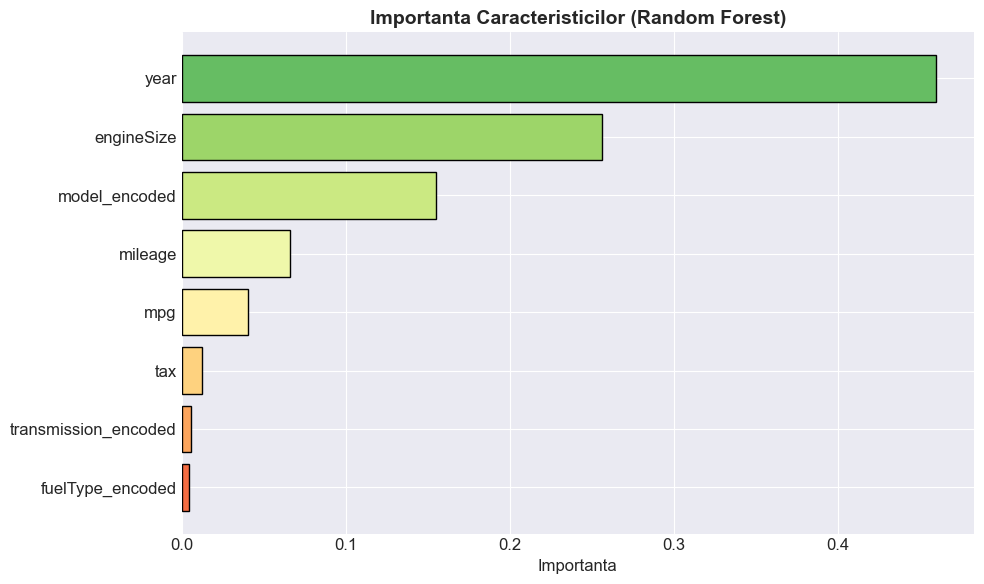

Caracteristicile cele mai importante pentru pret:
   - year: 46.0%
   - engineSize: 25.6%
   - model_encoded: 15.5%


In [22]:
# Importanta caracteristicilor (doar pentru Random Forest)
plt.figure(figsize=(10, 6))

rf_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

colors_importance = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(feature_cols)))
plt.barh(rf_importance['Feature'], rf_importance['Importance'], 
         color=colors_importance, edgecolor='black')
plt.xlabel('Importanta', fontsize=12)
plt.title('Importanta Caracteristicilor (Random Forest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('importanta_caracteristici.png', dpi=150, bbox_inches='tight')
plt.show()

print('Caracteristicile cele mai importante pentru pret:')
for _, row in rf_importance.sort_values('Importance', ascending=False).head(3).iterrows():
    print(f'   - {row["Feature"]}: {row["Importance"]*100:.1f}%')

## 7. De ce Random Forest functioneaza mai bine?

### Analiza comparativa a celor doua metode:

| Aspect | Linear Regression | Random Forest |
|--------|-------------------|---------------|
| **Complexitate** | Simpla (o ecuatie) | Complexa (100 arbori) |
| **Relatii non-liniare** | NU poate captura | DA, prin split-uri |
| **Interactiuni variabile** | NU | DA, prin ramificari |
| **Interpretabilitate** | Foarte usor | Mai dificil |
| **Timp antrenare** | Foarte rapid | Mai lent |

### Motivul principal al diferentei de performanta:

Datele noastre au **relatii non-liniare** (vizibile in graficele scatter):
- Pretul NU creste liniar cu anul
- Relatia pret-kilometraj este curba, nu dreapta
- Exista interactiuni complexe (ex: un motor mare pe o masina veche vs noua)

**Linear Regression** presupune ca:
```
pret = a + b1*year + b2*mileage + ...
```
Aceasta ecuatie liniara NU poate captura complexitatea reala a datelor.

**Random Forest** poate invata reguli de tipul:
```
DACA year > 2018 SI mileage < 20000 SI model = 'X5'
   ATUNCI pret ~ 45000
```
Aceasta flexibilitate ii permite sa modeleze relatiile complexe din date.

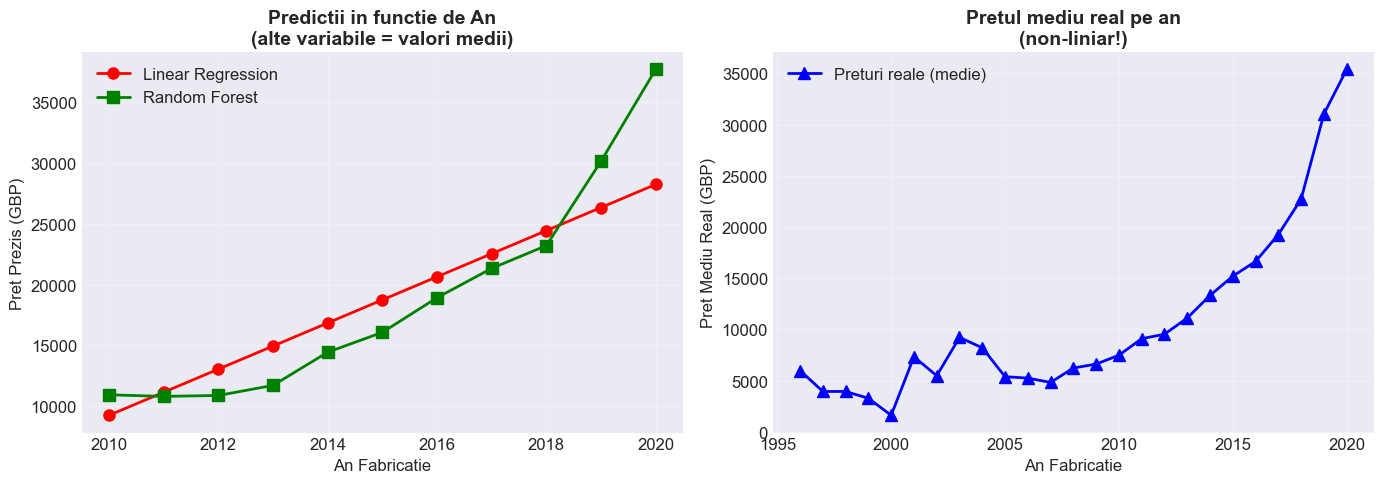

Observatii:
   - Linear Regression: Predictie strict liniara (linie dreapta)
   - Random Forest: Poate captura curbura reala a datelor
   - Datele reale au un pattern non-liniar (crestere accelerata in ultimii ani)


In [23]:
# Exemplu vizual: De ce Linear Regression esueaza la relatii non-liniare
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Simulam predictii pentru diferite valori de year (pastrand alte variabile la medie)
years_test = np.arange(2010, 2021)
mean_features = X_train.mean().values

# Cream date artificiale variind doar anul
test_data = []
for year in years_test:
    row = mean_features.copy()
    row[0] = year  # year este prima coloana
    test_data.append(row)
test_data = np.array(test_data)
test_data_scaled = scaler.transform(test_data)

lr_year_pred = lr_model.predict(test_data_scaled)
rf_year_pred = rf_model.predict(test_data_scaled)

# Grafic 1: Predictii in functie de an
axes[0].plot(years_test, lr_year_pred, 'r-o', linewidth=2, markersize=8, label='Linear Regression')
axes[0].plot(years_test, rf_year_pred, 'g-s', linewidth=2, markersize=8, label='Random Forest')
axes[0].set_xlabel('An Fabricatie', fontsize=12)
axes[0].set_ylabel('Pret Prezis (GBP)', fontsize=12)
axes[0].set_title('Predictii in functie de An\n(alte variabile = valori medii)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Grafic 2: Date reale grupate pe an
yearly_avg = df.groupby('year')['price'].mean()
axes[1].plot(yearly_avg.index, yearly_avg.values, 'b-^', linewidth=2, markersize=8, label='Preturi reale (medie)')
axes[1].set_xlabel('An Fabricatie', fontsize=12)
axes[1].set_ylabel('Pret Mediu Real (GBP)', fontsize=12)
axes[1].set_title('Pretul mediu real pe an\n(non-liniar!)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analiza_nonliniaritate.png', dpi=150, bbox_inches='tight')
plt.show()

print('Observatii:')
print('   - Linear Regression: Predictie strict liniara (linie dreapta)')
print('   - Random Forest: Poate captura curbura reala a datelor')
print('   - Datele reale au un pattern non-liniar (crestere accelerata in ultimii ani)')

## 8. Concluzii

### Rezumat Proiect

| Aspect | Detalii |
|--------|--------|
| **Problema** | Predictia pretului automobilelor BMW |
| **Tip invatare** | Supervizata - Regresie |
| **Dataset** | 10,781 vehicule BMW, 9 caracteristici |
| **Metode** | Linear Regression vs Random Forest |

In [24]:
# Sumar final
print('\n' + '='*70)
print('SUMAR FINAL AL PROIECTULUI')
print('='*70)

print(f'\nDate procesate: {len(df):,} vehicule BMW')
print(f'Problema: Predictia Pretului (Regresie Supervizata)')

print(f'\n' + '-'*70)
print('REZULTATE COMPARATIVE:')
print('-'*70)

print(f'\n1. LINEAR REGRESSION (metoda simpla):')
print(f'   - R2 Score: {lr_r2:.4f} ({lr_r2*100:.1f}%)')
print(f'   - MAE: {lr_mae:,.2f} GBP')
print(f'   - Limitare: NU poate captura relatii non-liniare')

print(f'\n2. RANDOM FOREST (metoda complexa):')
print(f'   - R2 Score: {rf_r2:.4f} ({rf_r2*100:.1f}%)')
print(f'   - MAE: {rf_mae:,.2f} GBP')
print(f'   - Avantaj: Capteaza relatii complexe si interactiuni')

print(f'\n' + '-'*70)
print('DIFERENTA DE PERFORMANTA:')
print('-'*70)
print(f'   Random Forest este cu {mae_improvement:.1f}% mai precis (MAE)')
print(f'   Random Forest explica cu {(rf_r2-lr_r2)*100:.1f}% mai mult din variatie')

print(f'\n' + '-'*70)
print('CONCLUZIE:')
print('-'*70)
print('   Random Forest este clar superior pentru acest dataset deoarece')
print('   relatiile dintre caracteristici si pret sunt NON-LINIARE.')
print('   Linear Regression, desi simpla si interpretabila, este inadecvata')
print('   pentru date cu relatii complexe.')



SUMAR FINAL AL PROIECTULUI

Date procesate: 10,781 vehicule BMW
Problema: Predictia Pretului (Regresie Supervizata)

----------------------------------------------------------------------
REZULTATE COMPARATIVE:
----------------------------------------------------------------------

1. LINEAR REGRESSION (metoda simpla):
   - R2 Score: 0.7410 (74.1%)
   - MAE: 3,996.76 GBP
   - Limitare: NU poate captura relatii non-liniare

2. RANDOM FOREST (metoda complexa):
   - R2 Score: 0.9443 (94.4%)
   - MAE: 1,633.08 GBP
   - Avantaj: Capteaza relatii complexe si interactiuni

----------------------------------------------------------------------
DIFERENTA DE PERFORMANTA:
----------------------------------------------------------------------
   Random Forest este cu 59.1% mai precis (MAE)
   Random Forest explica cu 20.3% mai mult din variatie

----------------------------------------------------------------------
CONCLUZIE:
----------------------------------------------------------------------
